<a href="https://colab.research.google.com/github/zhilyaevaviktorija/machine_learning/blob/main/homeworks/Homework_6_%22clustering_hw_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Кластеризация

###Часть 1. K‑Means

In [1]:
!wget https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv

--2026-05-03 18:12:53--  https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84143 (82K) [text/plain]
Saving to: ‘wineqr.csv’

wineqr.csv          100%[===================>]  82.17K  --.-KB/s    in 0.002s  

2026-05-03 18:12:53 (39.8 MB/s) - ‘wineqr.csv’ saved [84143/84143]



1. Загрузка и предобработка

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv('wineqr.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
# Удаление столбца quality
X = df.drop(columns=['quality'])

In [5]:
# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

2. K-Means с выбором K (локоть + силуэт)

In [6]:
# 1. Обучаем K-means, вычисляем WCSS и коэффициент силуэта
range_n_clusters = range(2, 11)
wcss = []
silhouette_scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    print(f"K={k}: WCSS={kmeans.inertia_:.1f}, Silhouette={sil:.3f}")

K=2: WCSS=14330.1, Silhouette=0.214
K=3: WCSS=12630.0, Silhouette=0.189
K=4: WCSS=11459.1, Silhouette=0.172
K=5: WCSS=10155.5, Silhouette=0.190
K=6: WCSS=9363.2, Silhouette=0.195
K=7: WCSS=8645.2, Silhouette=0.193
K=8: WCSS=8299.0, Silhouette=0.150
K=9: WCSS=7969.3, Silhouette=0.153
K=10: WCSS=7671.0, Silhouette=0.157


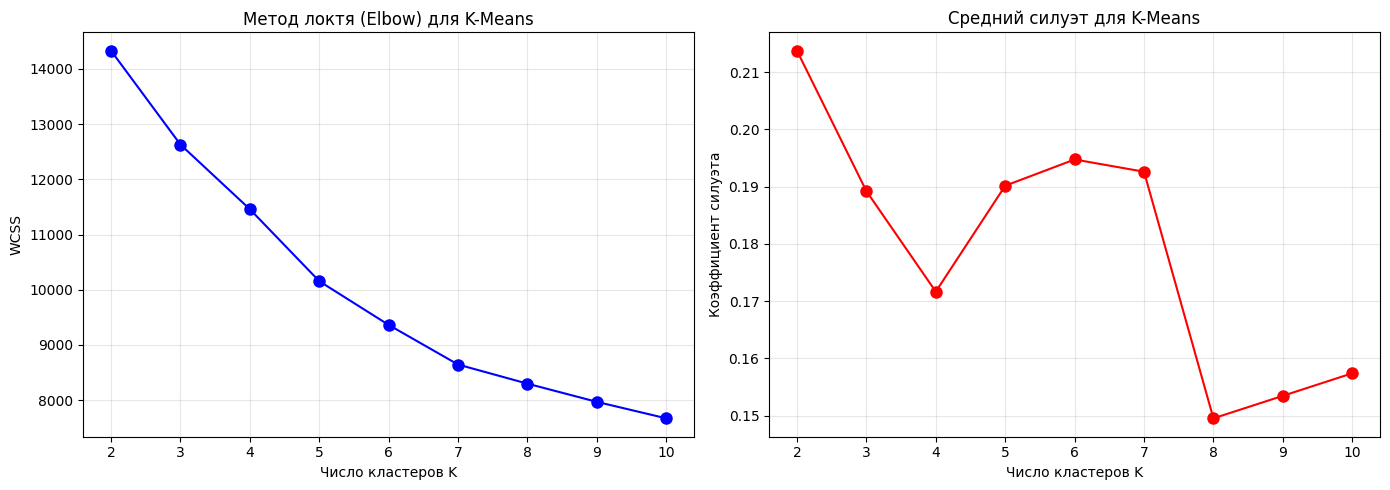

In [38]:
# 2. Строим два графика: метод локтя (WCSS) и средний силуэт

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range_n_clusters, wcss, 'bo-', markersize=8)
ax1.set_xlabel('Число кластеров K')
ax1.set_ylabel('WCSS')
ax1.set_title('Метод локтя (Elbow) для K-Means')
ax1.grid(True, alpha=0.3)

ax2.plot(range_n_clusters, silhouette_scores, 'ro-', markersize=8)
ax2.set_xlabel('Число кластеров K')
ax2.set_ylabel('Коэффициент силуэта')
ax2.set_title('Средний силуэт для K-Means')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# 3. Выбираем оптимальное K по силуэту

optimal_k = range_n_clusters[np.argmax(silhouette_scores)]
print(f"\nОптимальное число кластеров по силуэту: {optimal_k}")


Оптимальное число кластеров по силуэту: 2


In [9]:
# 4. Обучаем финальную модель K‑Means с выбранным K

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

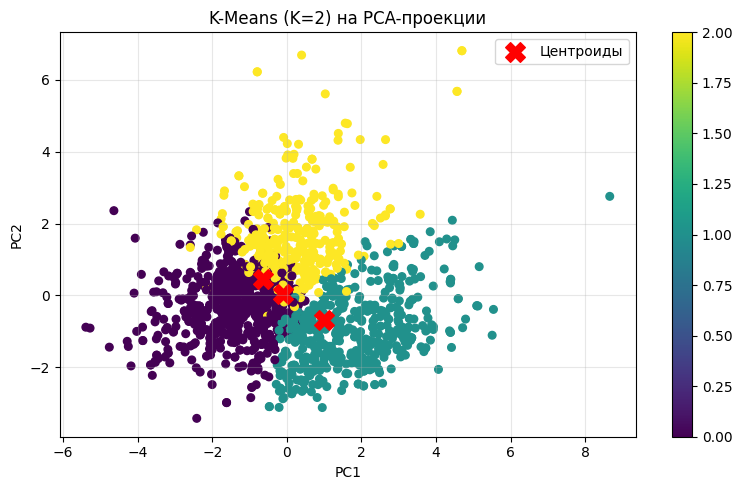

In [42]:
# 5. С помощью PCA (2 компоненты) визуализируем кластеры

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=30)
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
            marker='X', c='red', s=200, label='Центроиды')
plt.title(f'K-Means (K={optimal_k}) на PCA-проекции')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.colorbar(scatter)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# 6. Выводим силуэт финальной модели
final_silhouette = silhouette_score(X_scaled, kmeans_labels)
print(f"Silhouette Score финальной модели: {final_silhouette:.3f}")

Silhouette Score финальной модели: 0.189


###Часть 2. DBSCAN

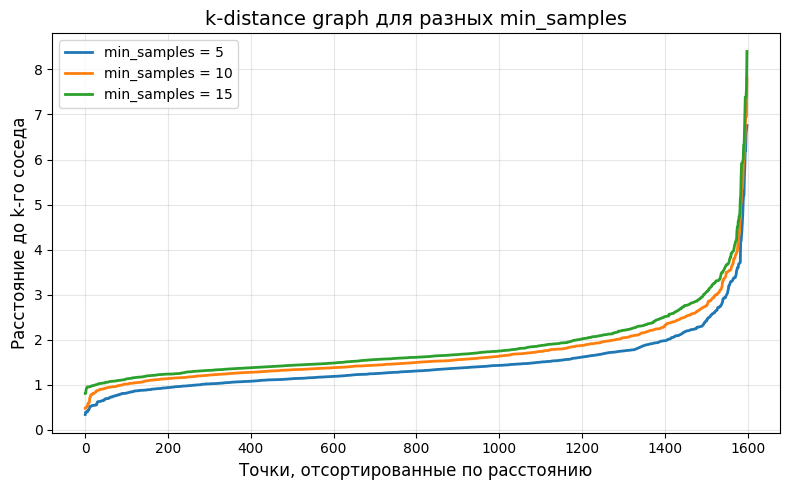

In [17]:
# 1. Строим k‑distance graph

plt.figure(figsize=(8, 5))
min_samples_list = [5, 10, 15]

for min_samples in min_samples_list:
    nn = NearestNeighbors(n_neighbors=min_samples)
    nn.fit(X_scaled)
    distances, _ = nn.kneighbors(X_scaled)
    k_distances = np.sort(distances[:, -1])
    plt.plot(range(len(k_distances)), k_distances,
             linewidth=2, label=f'min_samples = {min_samples}')

plt.xlabel('Точки, отсортированные по расстоянию', fontsize=12)
plt.ylabel('Расстояние до k-го соседа', fontsize=12)
plt.title('k‑distance graph для разных min_samples', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# 2. Методом перебора (eps от 0.3 до 1.1 с шагом 0.1, min_samples = 5, 10, 15) находим параметры, дающие максимальный силуэт
# (число кластеров ≥ 2, шум не более 80% данных)

eps_values = np.arange(0.3, 1.2, 0.1) # отбираем eps от 0.3 до 1.1 с шагом 0.1
min_samples_list = [5, 10, 15]

best_score = -1
best_params = None
best_labels = None

print("eps     min_samples     n_clusters     noise_percent     sil")

for eps in eps_values:
    for min_samples in min_samples_list:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_percent = (labels == -1).mean() * 100

        # Отбираем по условию: >=2 кластера и шум не более 80%
        if n_clusters >= 2 and noise_percent <= 80:
            mask = labels != -1
            if mask.sum() >= 2:  # нужно минимум 2 точки для силуэта
                sil = silhouette_score(X_scaled[mask], labels[mask])
            else:
                sil = -1
        else:
            sil = -1

        print(f"{eps:.1f}     {min_samples:3d}          {n_clusters:2d}           {noise_percent:5.1f}          {sil:.4f}")

        if sil > best_score:
            best_score = sil
            best_params = (eps, min_samples)
            best_labels = labels

# Выводим результаты поиска
if best_params is not None:
    print(f"\nЛучшие параметры: best_eps = {best_params[0]:.1f}, best_min_samples = {best_params[1]}")
    print(f"Silhouette Score: {best_score:.3f}")
    n_clusters_final = len(set(best_labels)) - (1 if -1 in best_labels else 0)
    noise_final = (best_labels == -1).mean() * 100
    print(f"Кластеров: {n_clusters_final}, шум: {noise_final:.1f}%")
else:
    print("\nНе найдено подходящих параметров (кластеров ≥2 и шум ≤80%).")

eps     min_samples     n_clusters     noise_percent     sil
0.3       5           0           100.0          -1.0000
0.3      10           0           100.0          -1.0000
0.3      15           0           100.0          -1.0000
0.4       5           1            99.5          -1.0000
0.4      10           0           100.0          -1.0000
0.4      15           0           100.0          -1.0000
0.5       5           3            98.7          -1.0000
0.5      10           1            99.4          -1.0000
0.5      15           0           100.0          -1.0000
0.6       5           7            97.2          -1.0000
0.6      10           1            99.3          -1.0000
0.6      15           0           100.0          -1.0000
0.7       5          10            95.1          -1.0000
0.7      10           1            99.1          -1.0000
0.7      15           0           100.0          -1.0000
0.8       5          10            92.5          -1.0000
0.8      10           4    

In [14]:
# 3. Обучаем DBSCAN с лучшими параметрами

db_best = DBSCAN(eps=best_params[0], min_samples=best_params[1])
best_labels = db_best.fit_predict(X_scaled)

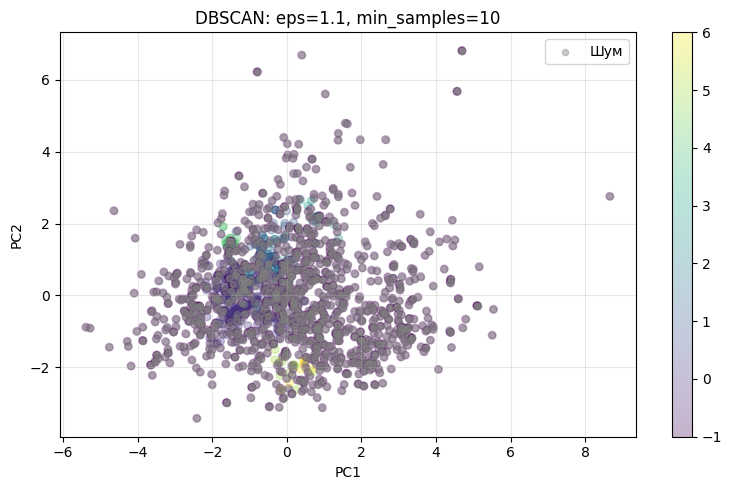

In [36]:
# 4. Визуализируем результат через PCA (точки шума — отдельным цветом/меткой)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels, cmap='viridis', s=30, alpha=0.3)

plt.scatter(X_pca[best_labels == -1, 0], X_pca[best_labels == -1, 1],
            c='grey', s=20, alpha=0.4, label='Шум')

plt.title(f'DBSCAN: eps={best_params[0]:.1f}, min_samples={best_params[1]}')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.colorbar(scatter)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###Вопросы по теме DBSCAN

| **1. Почему для DBSCAN критически важно масштабировать данные?** |
|:-----------------------------------------------------------------|
|Масштабирование данных критически важно, поскольку DBSCAN измеряет расстояние между точками (евклидово расстояние) и нивелирует разницу между признаками.|
| **2. Что будет при слишком маленьком eps? Слишком большом?** |
|Это наиболее важный параметр DBSCAN, который необходимо правильно выбрать для набора данных и функции расстояния. Меньшие значения обычно приводят к большему количеству кластеров и наоборот.|
| **3. Что означают точки с меткой -1?**|
|Это шум, такие точки не принадлежат ни к какому кластеру.|
| **4. Чем DBSCAN принципиально отличается от K‑Means по форме кластеров?**|
|DBSCAN находит кластеры любой формы, потому что он соединяет точки через цепочки соседей по плотности. K‑Means всегда рисует круглые кластеры, потому что он опирается на центроиды.|

###Часть 3. OPTICS

In [22]:
from sklearn.cluster import OPTICS

In [23]:
# 1. Обучаем OPTICS
optics = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05)
optics_labels = optics.fit_predict(X_scaled)

In [31]:
# 2. Выводим результаты
n_clusters_optics = len(set(optics_labels)) - (1 if -1 in optics_labels else 0)
n_noise_optics = list(optics_labels).count(-1)
noise_percent_optics = (n_noise_optics / len(optics_labels)) * 100

# Вычисляем коэффициент силуэта (при количестве кластеров >= 1)
if n_clusters_optics > 1:
    silhouette_optics = silhouette_score(X_scaled, optics_labels)
else:
    silhouette_optics = -1

print(f"Количество кластеров: {n_clusters_optics}")
print(f"Количество шума: {n_noise_optics} ({noise_percent_optics:.1f}%)")
print(f"Коэффициент силуэта: {silhouette_optics:.3f}")

Количество кластеров: 1
Количество шума: 0 (0.0%)
Коэффициент силуэта: -1.000


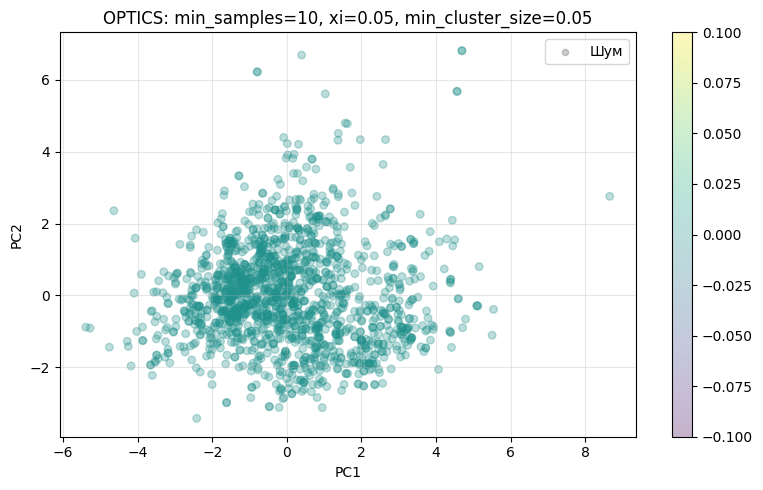

In [35]:
# 3. Визуализация через PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=optics_labels, cmap='viridis', s=30, alpha=0.3)

plt.scatter(X_pca[optics_labels == -1, 0], X_pca[optics_labels == -1, 1],
            c='grey', s=20, alpha=0.4, label='Шум')

plt.title(f'OPTICS: min_samples=10, xi=0.05, min_cluster_size=0.05')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.colorbar(scatter)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

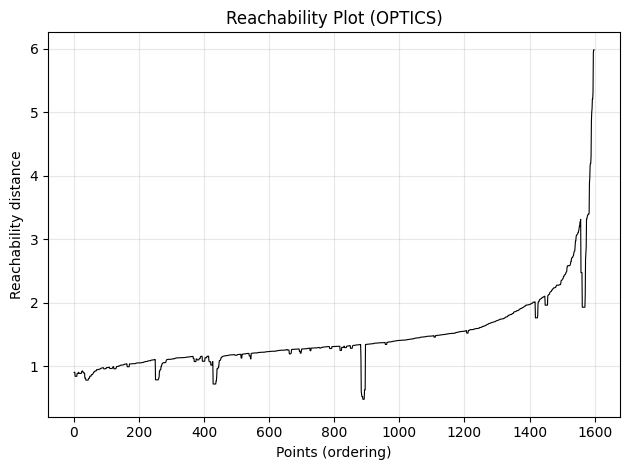

In [39]:
# 4. Выводим reachability plot (график достижимости)

reachability = optics.reachability_[optics.ordering_]
plt.plot(range(len(reachability)), reachability, 'k-', linewidth=0.8)
plt.title('Reachability Plot (OPTICS)')
plt.xlabel('Points (ordering)')
plt.ylabel('Reachability distance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
# Вычисляем лучшее время работы

from sklearn.cluster import DBSCAN, OPTICS
import time

# DBSCAN
start = time.time()
dbscan = DBSCAN(eps=0.5, min_samples=10)
db_labels = dbscan.fit_predict(X_scaled)
db_time = time.time() - start

# OPTICS
start = time.time()
optics = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05)
opt_labels = optics.fit_predict(X_scaled)
opt_time = time.time() - start

print(f"DBSCAN time: {db_time:.4f} сек")
print(f"OPTICS time: {opt_time:.4f} сек")

DBSCAN time: 0.1241 сек
OPTICS time: 3.5328 сек


###Вопросы по теме OPTICS

| **1. Чем OPTICS отличается от DBSCAN? Укажите два ключевых отличия.** |
|:---------------------------------------------------------------|
| OPTICS (Ordering Points To Identify the Clustering Structure, «упорядочивание точек для определения кластерной структуры»), тесно связанный с алгоритмом DBSCAN, находит основные образцы с высокой плотностью и расширяет кластеры от них.
В отличие от DBSCAN, он сохраняет иерархию кластеров при переменном радиусе окрестности. Лучше подходит для работы с большими наборами данных, чем текущая реализация DBSCAN в scikit-learn. |
| **2. Что такое параметр xi (кси) и как он влияет на выделение кластеров?**|
| Это число от 0 до 1, по умолчанию 0,05. Определяет минимальное steepness на графике достижимости, которая образует границу кластера.
Например, восходящая точка на графике достижимости определяется соотношением между расстоянием от одной точки до следующей и значением не более 1-xi. Используется только в случае cluster_method='xi'. |
| **3. В каком случае OPTICS даст результат, существенно лучший, чем DBSCAN? Приведите пример.** |
| OPTICS работает с кластерами разной плотности лучше, чем DBSCAN. DBSCAN требует единого eps для всех кластеров, а OPTICS автоматически адаптируется к переменной плотности.
Например, DBSCAN не сможет выделить данные с плотным компактным кластером и разреженным вытянутым кластером правильно, а OPTICS - сможет. |
| **4. Сравните время работы DBSCAN и OPTICS на ваших данных (можно замерить через %timeit или time.time()).** |
| DBSCAN time: 0.1241 сек
OPTICS time: 3.5328 сек
OPTICS работает медленнее DBSCAN, поскольку он строит полный график достижимости, а не просто кластеризует с фиксированным eps. |
| **5. Судя по визуализациям, какой алгоритм (K‑Means, DBSCAN, OPTICS) лучше разделил данные? Почему?** |
| Лучше всего разделил данные алгоритм K‑Means, поскольку он выделил несколько четко разделимых кластеров с центроидами.
Несмотря на 77,2% шума, DBSCAN довольно неплохо выделил 7 кластеров. Можно попробовать увеличить значение eps, чтобы снизить долю шума и вывести более качественный результат.
Худший результат показал OPTICS, поскольку на визуализации кластеры почти не выделяются. Этот алгоритм лучше применять на других данных. |